**data Load**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:


# Go up one level from Notebook folder to the project root
os.chdir(r'C:\Users\workstation\Desktop\customer_churn_prediction')

# Verify
print(os.getcwd())

C:\Users\workstation\Desktop\customer_churn_prediction


In [4]:
# Load helper
def load_logs(filepath):
    chunks = []
    for chunk in pd.read_csv(filepath, chunksize=1_000_000):
        chunk['date'] = pd.to_datetime(chunk['date'], format='%Y%m%d')
        chunks.append(chunk)
    return pd.concat(chunks)



In [5]:
# 1. User Logs 
logs = pd.concat([
    load_logs(r'data\raw\User_logs.csv'),
    load_logs(r'data\raw\User_logs_v2.csv')
], ignore_index=True)

In [6]:
print(f"Dataset shape {logs.shape[0]} rows x {logs.shape[1]}")
print(f"   First 3 rows:\n{logs.head(3)}")


Dataset shape 410502905 rows x 9
   First 3 rows:
                                           msno       date  num_25  num_50  \
0  rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34= 2015-05-13       0       0   
1  rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34= 2015-07-09       9       1   
2  yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8= 2015-01-05       3       3   

   num_75  num_985  num_100  num_unq  total_secs  
0       0        0        1        1     280.335  
1       0        0        7       11    1658.948  
2       0        0       68       36   17364.956  


In [7]:
# 2. Transactions 
trans = pd.concat([
    pd.read_csv(r'data\raw\transactions_v2.csv'),
    pd.read_csv(r'data\raw\transactions.csv')
], ignore_index=True)

In [8]:
print(f"Dataset shape {trans.shape[0]} rows x {trans.shape[1]}")
print(f"   First 3 rows:\n{trans.head(3)}")

Dataset shape 22978755 rows x 9
   First 3 rows:
                                           msno  payment_method_id  \
0  ++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=                 32   
1  ++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=                 41   
2  +/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=                 36   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 90              298                 298              0   
1                 30              149                 149              1   
2                 30              180                 180              1   

   transaction_date  membership_expire_date  is_cancel  
0          20170131                20170504          0  
1          20150809                20190412          0  
2          20170303                20170422          0  


In [ ]:
#3. members
members = pd.read_csv(r'data\raw\members_v3.csv').set_index('msno')


In [19]:
print(f"Dataset shape {members.shape[0]} rows x {members.shape[1]}")
print(f"   First 3 rows:\n{members.head(3)}")

Dataset shape 6769473 rows x 5
   First 3 rows:
                                              city  bd gender  registered_via  \
msno                                                                            
Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=     1   0    NaN              11   
+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=     1   0    NaN               7   
cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=     1   0    NaN              11   

                                              registration_init_time  
msno                                                                  
Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=                20110911  
+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=                20110914  
cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=                20110915  


In [ ]:
#4. train
train = pd.concat([
    pd.read_csv(r'data\raw\train_v2.csv'),
    pd.read_csv(r'data\raw\train.csv')
], ignore_index=True)

In [20]:
print(f"Dataset shape {train.shape[0]} rows x {train.shape[1]}")
print(f"   First 3 rows:\n{train.head(3)}")

Dataset shape 1963891 rows x 2
   First 3 rows:
                                           msno  is_churn
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=         1
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=         1
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=         1


In [1]:

data_source_report = {
    "source": "Kaggle",
    "competition": "WSDM - KKBox's Churn Prediction Challenge",
    "url": "https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge",
    "acquisition_method": "CSV download from Kaggle Competition page",
    "date_acquired": "2026-4-24", 
    "files": {
        "User_logs.csv"         : "Daily user listening behavior (original)",
        "User_logs_v2.csv"      : "Daily user listening behavior (updated)",
        "transactions.csv"      : "User subscription transactions (original)",
        "transactions_v2.csv"   : "User subscription transactions (updated)",
        "members_v3.csv"        : "User demographic information (latest)",
        "train_v2.csv"          : "Training labels - churn or not churn",
        "sample_submission_v2.csv" : "Submission format template",
        "sample_submission_zero.csv": "Baseline submission (all zeros)"
    },
    "issues_encountered": [
        "User_logs files are ~30 GB — requires chunked loading",
        "Notebook is in subfolder — requires os.chdir() to set correct working directory",
        "members.csv and members_v2.csv not available — only members_v3.csv",
        "Some columns contained invalid or inconsistent values. For example, the bd (age) column included unrealistic values such as negative numbers or extremely large ages, requiring cleaning and filtering.",
       "Several fields, especially gender, had a high percentage of missing values, which made feature engineering more challenging.",
        "Some age (bd) values are invalid — negative or above 100",
        "Combining data from different sources (transactions, user_logs, and members) required careful merging and alignment using the user ID (msno).",
        "Missing values in gender column"
    ]
}


for key, value in data_source_report.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        for k, v in value.items():
            print(f"   {k:30} : {v}")
    elif isinstance(value, list):
        print(f"\n{key}:")
        for item in value:
            print(f"   - {item}")
    else:
        print(f"{key:25} : {value}")

source                    : Kaggle
competition               : WSDM - KKBox's Churn Prediction Challenge
url                       : https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge
acquisition_method        : CSV download from Kaggle Competition page
date_acquired             : 2026-4-24

files:
   User_logs.csv                  : Daily user listening behavior (original)
   User_logs_v2.csv               : Daily user listening behavior (updated)
   transactions.csv               : User subscription transactions (original)
   transactions_v2.csv            : User subscription transactions (updated)
   members_v3.csv                 : User demographic information (latest)
   train_v2.csv                   : Training labels - churn or not churn
   sample_submission_v2.csv       : Submission format template
   sample_submission_zero.csv     : Baseline submission (all zeros)

issues_encountered:
   - User_logs files are ~30 GB — requires chunked loading
   - Notebook is

**Data Describe**

In [12]:
# 1. User Logs 
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410502905 entries, 0 to 410502904
Data columns (total 9 columns):
 #   Column      Dtype         
---  ------      -----         
 0   msno        object        
 1   date        datetime64[ns]
 2   num_25      int64         
 3   num_50      int64         
 4   num_75      int64         
 5   num_985     int64         
 6   num_100     int64         
 7   num_unq     int64         
 8   total_secs  float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 27.5+ GB


Shape: 410,502,905 rows — extremely large dataset requiring chunked loading and memory optimization.

msno: Object dtype — user ID, no issues expected but takes significant memory at this scale.

date: Correctly stored as datetime64 — conversion was already applied successfully.

num_25, num_50, num_75, num_985, num_100, num_unq: All stored as int64 — this is wasteful since values are small numbers. Should be downcast to int16 to save approximately 19 GB of RAM.

total_secs: Stored as float64 — can be downcast to float32 to save memory. Contains severe negative values as seen in the describe output.

Memory: 27.5 GB — dangerously high. Applying int16 and float32 downcasting will bring this down to approximately 7–8 GB which is much more manageable.

Nulls: No null values in any column — confirmed by all columns showing same count as RangeIndex.

In [27]:
logs.sample(100_000).describe()

,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,100000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2016-03-14 05:30:14.976000256,6.480150,1.615550,1.01263,1.127230,30.799000,30.060350,-9.223372e+11
min,2015-01-01 00:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,-9.223372e+15
25%,2015-08-31 00:00:00,0.000000,0.000000,0.00000,0.000000,6.000000,8.000000,1.895717e+03
50%,2016-03-30 00:00:00,2.000000,1.000000,0.00000,0.000000,17.000000,19.000000,4.620472e+03
75%,2016-10-06 00:00:00,7.000000,2.000000,1.00000,1.000000,38.000000,40.000000,1.030861e+04
max,2017-03-31 00:00:00,920.000000,240.000000,288.00000,184.000000,1759.000000,864.000000,1.856776e+06
std,NaN,14.124058,3.974967,2.44422,2.811331,42.289755,33.682798,9.222957e+13


In [28]:
logs.sample(1_000_000).describe()

,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,2016-03-13 19:55:05.779200256,6.510034,1.629644,1.015735,1.126437,30.709793,30.064809,-1.411176e+12
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-9.223372e+15
25%,2015-08-29 00:00:00,0.000000,0.000000,0.000000,0.000000,6.000000,8.000000,1.896485e+03
50%,2016-03-29 00:00:00,2.000000,1.000000,0.000000,0.000000,17.000000,19.000000,4.632372e+03
75%,2016-10-06 00:00:00,7.000000,2.000000,1.000000,1.000000,38.000000,40.000000,1.024601e+04
max,2017-03-31 00:00:00,1598.000000,545.000000,239.000000,259.000000,9458.000000,1694.000000,5.880314e+06
std,NaN,14.197227,4.219579,2.141496,2.779659,42.759858,33.709124,1.140781e+14


date:   Range is from January 2015 to March 2017 which covers about 2 years of listening history. The median date is March 2016 meaning the data is fairly evenly distributed across the time period. No issues with this column after datetime conversion.

num_25 (songs played at 25% completion):   Heavily right skewed — median is only 2 but maximum is 1598 which is an extreme outlier. Mean (6.5) is much higher than median (2) confirming the skew. IQR is 7 (0 to 7). More than 25% of sessions have zero songs played at 25% meaning users either skip immediately or listen fully. High maximum suggests some power users who skip through hundreds of songs.

num_50 (songs played at 50% completion):   Same right skewed pattern. Median is 1 and mean is 1.6 — most users only get to the halfway point of 1 song per session. Maximum of 545 is an extreme outlier. IQR is very small (0 to 2) meaning most users have very low values here.

num_75 (songs played at 75% completion):   Even more skewed than num_50. Median is 0 meaning more than 50% of sessions have no songs reaching 75% completion. Mean is 1.0 pulled up by outliers. Maximum of 239. IQR is 0 to 1. Users who reach 75% of a song almost always finish it — so this column adds limited extra information beyond num_100.

num_985 (songs played at 98.5% completion):   Very similar to num_75. Median is 0 and mean is 1.1. Maximum is 259. IQR is 0 to 1. Highly right skewed. This column is very close to num_100 in behavior and the two are likely highly correlated.

num_100 (songs played to full completion):   The most important play count column. Mean (30.7) is much higher than num_25 mean (6.5) which seems counterintuitive — it means users tend to either skip songs very early or finish them completely, rarely stopping in the middle.
Median is 17 and maximum is 9458 which is a massive outlier. IQR is 6 to 38. Heavily right skewed. This is the strongest engagement signal among the play count columns.

num_unq (unique songs played):   Very similar distribution to num_100. Mean is 30 and median is 19. Maximum of 1694 is an outlier. IQR is 8 to 40. Right skewed. High correlation with num_100 expected. Useful for measuring variety of listening behavior.

total_secs:   This column has a critical data quality problem. The mean is -1.41 trillion and minimum is -9.22 quadrillion which are completely impossible values — total seconds listened cannot be negative. This means there are severe data entry errors or integer overflow issues in this column. The 25th percentile (1,896 seconds = ~31 minutes) and 75th percentile (10,246 seconds = ~2.8 hours) look reasonable, but the negative values are completely destroying the mean and std. The std of 1.14 × 10^14 is meaningless. Maximum of 5,880,314 seconds = ~68 days which is also impossible for a single day of listening and needs to be capped at 86,400 seconds (24 hours).


In [14]:
# 2. Transactions 
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22978755 entries, 0 to 22978754
Data columns (total 9 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   payment_method_id       int64 
 2   payment_plan_days       int64 
 3   plan_list_price         int64 
 4   actual_amount_paid      int64 
 5   is_auto_renew           int64 
 6   transaction_date        int64 
 7   membership_expire_date  int64 
 8   is_cancel               int64 
dtypes: int64(8), object(1)
memory usage: 1.5+ GB



Shape: 22,978,755 rows — manageable size, no chunking needed.

msno: Object dtype — user ID, no issues.

payment_method_id, payment_plan_days, plan_list_price, actual_amount_paid, is_auto_renew, is_cancel: All int64 — can be downcast to int16 or int32 to save memory.

transaction_date, membership_expire_date: Stored as int64 in format 20170101 — must be converted to datetime64 before any time-based analysis.

Memory: Only 1.5 GB — no memory concerns here.



In [15]:
trans.describe()

,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
count,2.297876e+07,2.297876e+07,2.297876e+07,2.297876e+07,2.297876e+07,2.297876e+07,2.297876e+07,2.297876e+07
mean,3.886991e+01,3.349869e+01,1.487220e+02,1.506641e+02,8.478146e-01,2.015828e+07,2.015940e+07,3.881777e-02
std,3.624149e+00,3.985553e+01,1.704513e+02,1.714614e+02,3.592005e-01,6.627848e+03,8.128208e+03,1.931604e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.015010e+07,1.970010e+07,0.000000e+00
25%,3.800000e+01,3.000000e+01,9.900000e+01,9.900000e+01,1.000000e+00,2.015092e+07,2.015110e+07,0.000000e+00
50%,4.100000e+01,3.000000e+01,1.490000e+02,1.490000e+02,1.000000e+00,2.016041e+07,2.016053e+07,0.000000e+00
75%,4.100000e+01,3.000000e+01,1.490000e+02,1.490000e+02,1.000000e+00,2.016102e+07,2.016113e+07,0.000000e+00
max,4.100000e+01,4.500000e+02,2.000000e+03,2.000000e+03,1.000000e+00,2.017033e+07,2.036102e+07,1.000000e+00


payment_method_id:    Most users use payment methods 38–41, with the data left skewed and a very small IQR of 3. The minimum value is 1 which represents very old or rare payment methods. Should be treated as categorical not numerical.

payment_plan_days:    More than 50% of all transactions are exactly 30-day plans making the IQR equal to zero. The mean (33.5) is pulled up by extreme values like the maximum of 450 days. The minimum of 0 is invalid since a plan must have at least 1 day. Heavily right skewed.

plan_list_price:    Two dominant price points at 99 and 149 with IQR of 50. The standard deviation (170) is larger than the mean (148) giving a CV of 1.15 which indicates extremely high variance. Minimum of 0 suggests free plans or bad data. Maximum of 2000 is an extreme outlier pulling the mean up. Right skewed.

actual_amount_paid:   Almost identical distribution to plan_list_price. Interestingly the mean amount paid (150.6) is slightly higher than the mean list price (148.7) which is worth investigating. Minimum of 0 and maximum of 2000 need to be handled. A discount feature can be created by subtracting actual_amount_paid from plan_list_price.

is_auto_renew: Clean binary column with no issues. 84.8% of transactions have auto renew on and only 15.2% are manual renewals. This is one of the strongest churn signals in the dataset — users who turn off auto renew are much more likely to churn.

transaction_date:   Stored as integer in format 20150101 and needs to be converted to datetime. Range is from January 2015 to March 2017 which looks valid.

membership_expire_date:   Stored as integer and needs datetime conversion. Has serious data quality issues — minimum is 19700101 which is the Unix epoch default meaning completely invalid, and maximum is 20361020 which is 19 years in the future and also impossible. Only dates between 2015 and 2018 should be kept.

is_cancel:   Clean binary column. Only 3.9% of transactions are cancellations making it very imbalanced, but even though it is rare it is a very strong churn predictor. Any cancellation history significantly increases churn probability.

In [26]:
trans.nunique()

msno                      2426143
payment_method_id              40
payment_plan_days              37
plan_list_price                55
actual_amount_paid             65
is_auto_renew                   2
transaction_date              821
membership_expire_date       3473
is_cancel                       2
dtype: int64

In [16]:
#3. members
members.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6769473 entries, Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8= to isBt+JlgvZRNy6lxVr5vvuJ4lD00ofTaKyJ+uRnGcPg=
Data columns (total 5 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   city                    int64 
 1   bd                      int64 
 2   gender                  object
 3   registered_via          int64 
 4   registration_init_time  int64 
dtypes: int64(4), object(1)
memory usage: 309.9+ MB


Shape: 6,769,473 rows — small and manageable.

msno: Set as index — good practice for joining with other tables.

city, bd, registered_via, registration_init_time: All int64 — can be downcast to save memory.

gender: Object dtype — only non-numeric column. Has missing values that are not visible in info but confirmed from context. Missing values should be kept as a third category.

Memory: Only 309 MB — no memory concerns at all.




In [17]:
members.describe()

,city,bd,registered_via,registration_init_time
count,6.769473e+06,6.769473e+06,6.769473e+06,6.769473e+06
mean,3.847358e+00,9.795794e+00,5.253069e+00,2.014518e+07
std,5.478359e+00,1.792590e+01,2.361398e+00,2.318601e+04
min,1.000000e+00,-7.168000e+03,-1.000000e+00,2.004033e+07
25%,1.000000e+00,0.000000e+00,4.000000e+00,2.014042e+07
50%,1.000000e+00,0.000000e+00,4.000000e+00,2.015101e+07
75%,4.000000e+00,2.100000e+01,7.000000e+00,2.016060e+07
max,2.200000e+01,2.016000e+03,1.900000e+01,2.017043e+07


city: Heavily right skewed with median of 1 meaning more than half of all users are from City 1. Mean is 3.85 with a high CV of 1.42 reflecting the extreme concentration in one city. Range is 1 to 22. Should be treated as categorical and a binary feature of City 1 vs others could be useful.

bd (age): The most problematic column in the dataset. Minimum is -7168 and maximum is 2016 which are completely impossible values. Median is 0 meaning more than 50% of users have age stored as 0 which actually represents missing data. The mean of 9.8 is completely meaningless due to all the zeros and garbage values. After cleaning, only values between 1 and 99 should be kept and everything else replaced with NaN.

registered_via: 50% of users registered via methods 4 to 7 with IQR of 3. Minimum of -1 is invalid and needs to be removed. Should be treated as categorical. Range of valid values is 1 to 19.

registration_init_time: Stored as integer in format 20140101 and needs datetime conversion. Range is from 2004 to 2017 meaning some users have been on the platform for over 13 years. After conversion this column becomes very valuable for creating a tenure feature by calculating how long a user has been a member before churning.

gender: Not shown in describe since it is a text column but it has missing values. The missing values should be kept as a third category rather than being dropped since the fact that gender is unknown could itself carry predictive signal.



In [36]:
members.nunique()

city                        21
bd                         386
gender                       2
registered_via              18
registration_init_time    4782
reg_year                    14
dtype: int64

In [ ]:
#4. train
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1963891 entries, 0 to 1963890
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   msno      object
 1   is_churn  int64 
dtypes: int64(1), object(1)
memory usage: 30.0+ MB


**data explore**

C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\3214858916.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1][3].boxplot(


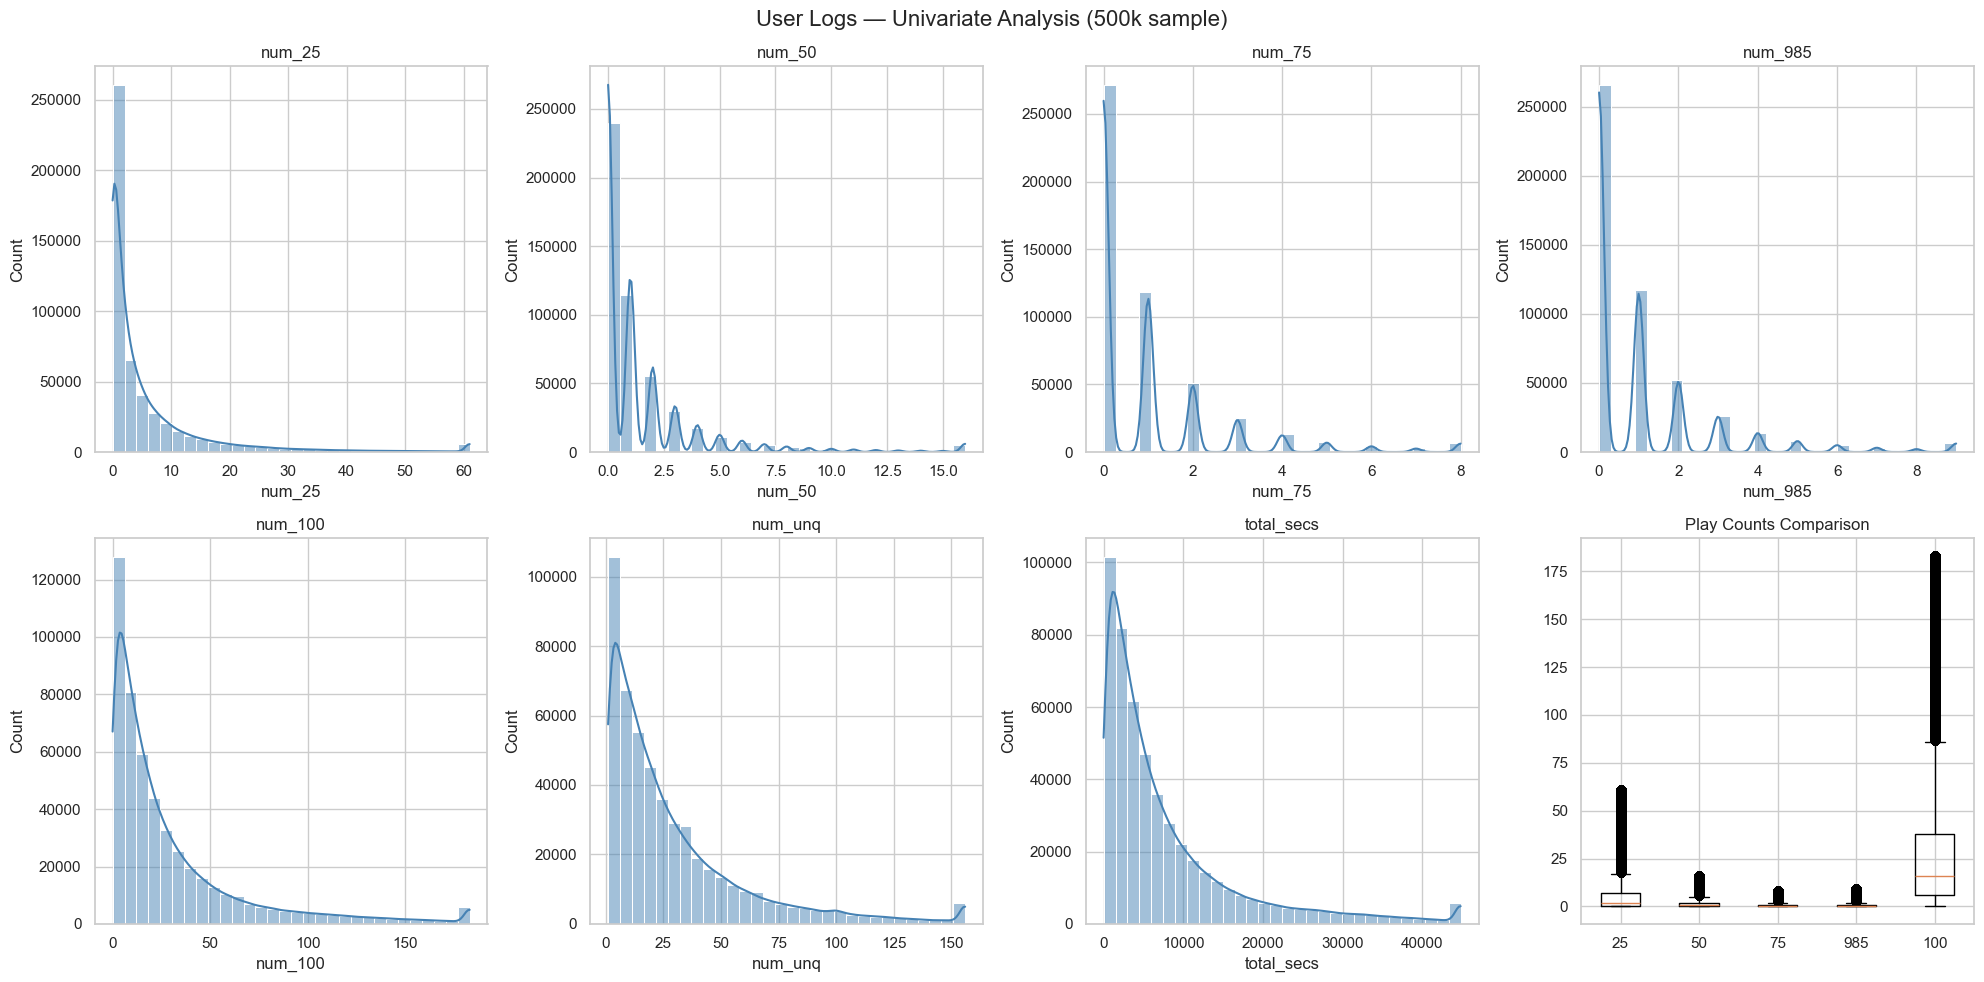

In [34]:
#1- USER LOGS
sample = logs.sample(500_000, random_state=42)
sample = sample[sample['total_secs'] > 0]
sample['total_secs'] = sample['total_secs'].clip(upper=86400)

play_cols = ['num_25','num_50','num_75','num_985','num_100','num_unq','total_secs']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('User Logs — Univariate Analysis (500k sample)', fontsize=16)

for i, col in enumerate(play_cols):
    ax = axes[i // 4][i % 4]
    cap = sample[col].quantile(0.99)
    sns.histplot(sample[col].clip(upper=cap), bins=30,
                 ax=ax, color='steelblue', kde=True)
    ax.set_title(col)

# all play counts boxplot together
axes[1][3].boxplot(
    [sample[c].clip(upper=sample[c].quantile(0.99))
     for c in ['num_25','num_50','num_75','num_985','num_100']],
    labels=['25','50','75','985','100'])
axes[1][3].set_title('Play Counts Comparison')

plt.tight_layout()
plt.show()

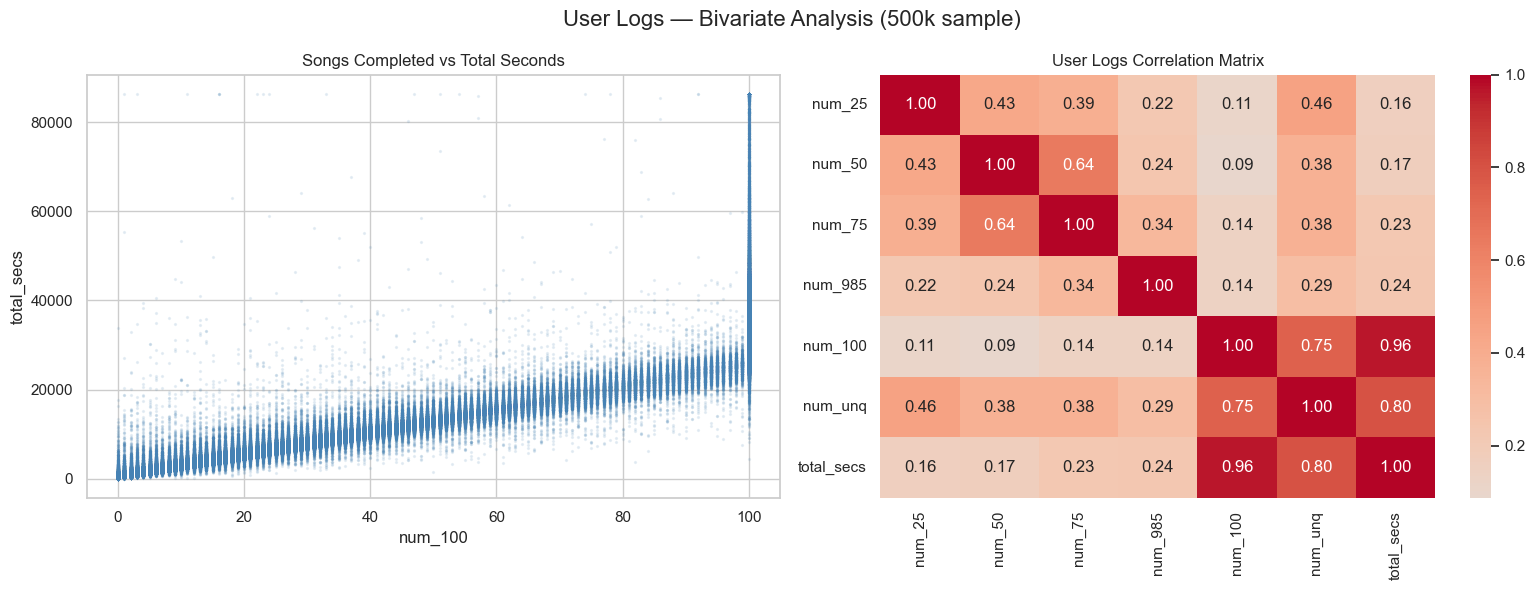

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('User Logs — Bivariate Analysis (500k sample)', fontsize=16)

# num_100 vs total_secs
axes[0].scatter(sample['num_100'].clip(upper=100),
                sample['total_secs'],
                alpha=0.1, s=2, color='steelblue')
axes[0].set_title('Songs Completed vs Total Seconds')
axes[0].set_xlabel('num_100')
axes[0].set_ylabel('total_secs')

# correlation heatmap
corr_logs = sample[play_cols].corr()
sns.heatmap(corr_logs, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('User Logs Correlation Matrix')

plt.tight_layout()
plt.show()

C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\3976827177.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_auto_renew', data=trans, ax=axes[1,0],
C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\3976827177.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['No','Yes'])
C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\3976827177.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_cancel', data=trans, ax=axes[1,1],
C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\3976827177.py:37: UserWarning: set_ticklabels() should only be used 

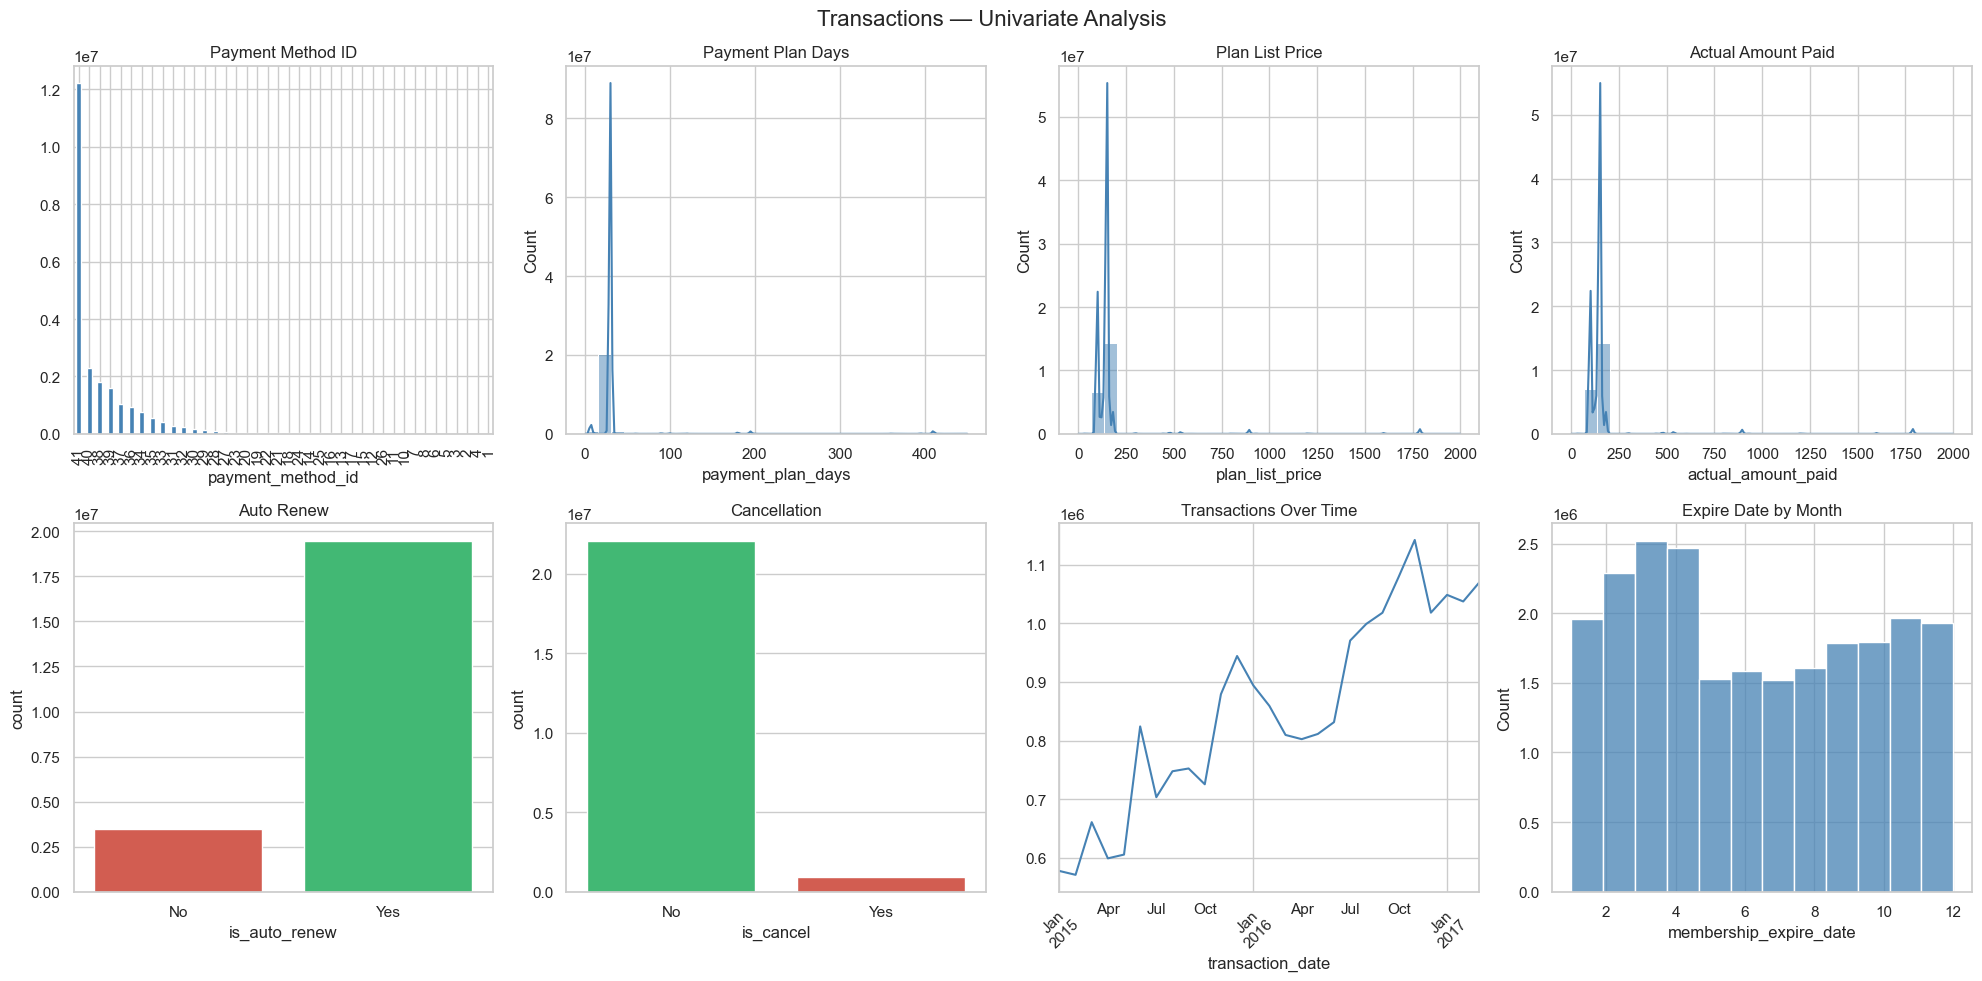

In [30]:
# 2- TRANSACTIONS 

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Transactions — Univariate Analysis', fontsize=16)

# payment_method_id
trans['payment_method_id'].value_counts()\
    .plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Payment Method ID')
axes[0,0].tick_params(axis='x', rotation=90)

# payment_plan_days
sns.histplot(trans[trans['payment_plan_days'] > 0]['payment_plan_days'],
             bins=30, ax=axes[0,1], color='steelblue', kde=True)
axes[0,1].set_title('Payment Plan Days')

# plan_list_price
sns.histplot(trans[trans['plan_list_price'] > 0]['plan_list_price'],
             bins=30, ax=axes[0,2], color='steelblue', kde=True)
axes[0,2].set_title('Plan List Price')

# actual_amount_paid
sns.histplot(trans[trans['actual_amount_paid'] > 0]['actual_amount_paid'],
             bins=30, ax=axes[0,3], color='steelblue', kde=True)
axes[0,3].set_title('Actual Amount Paid')

# is_auto_renew
sns.countplot(x='is_auto_renew', data=trans, ax=axes[1,0],
              palette=['#e74c3c','#2ecc71'])
axes[1,0].set_title('Auto Renew')
axes[1,0].set_xticklabels(['No','Yes'])

# is_cancel
sns.countplot(x='is_cancel', data=trans, ax=axes[1,1],
              palette=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Cancellation')
axes[1,1].set_xticklabels(['No','Yes'])

# transaction_date over time
trans['transaction_date'] = pd.to_datetime(
    trans['transaction_date'], format='%Y%m%d', errors='coerce')
trans.groupby(trans['transaction_date'].dt.to_period('M')).size()\
     .plot(ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Transactions Over Time')
axes[1,2].tick_params(axis='x', rotation=45)

# membership_expire_date by month
trans['membership_expire_date'] = pd.to_datetime(
    trans['membership_expire_date'], format='%Y%m%d', errors='coerce')
valid_expire = trans[trans['membership_expire_date'].dt.year.between(2015, 2018)]
sns.histplot(valid_expire['membership_expire_date'].dt.month,
             bins=12, ax=axes[1,3], color='steelblue')
axes[1,3].set_title('Expire Date by Month')

plt.tight_layout()
plt.show()


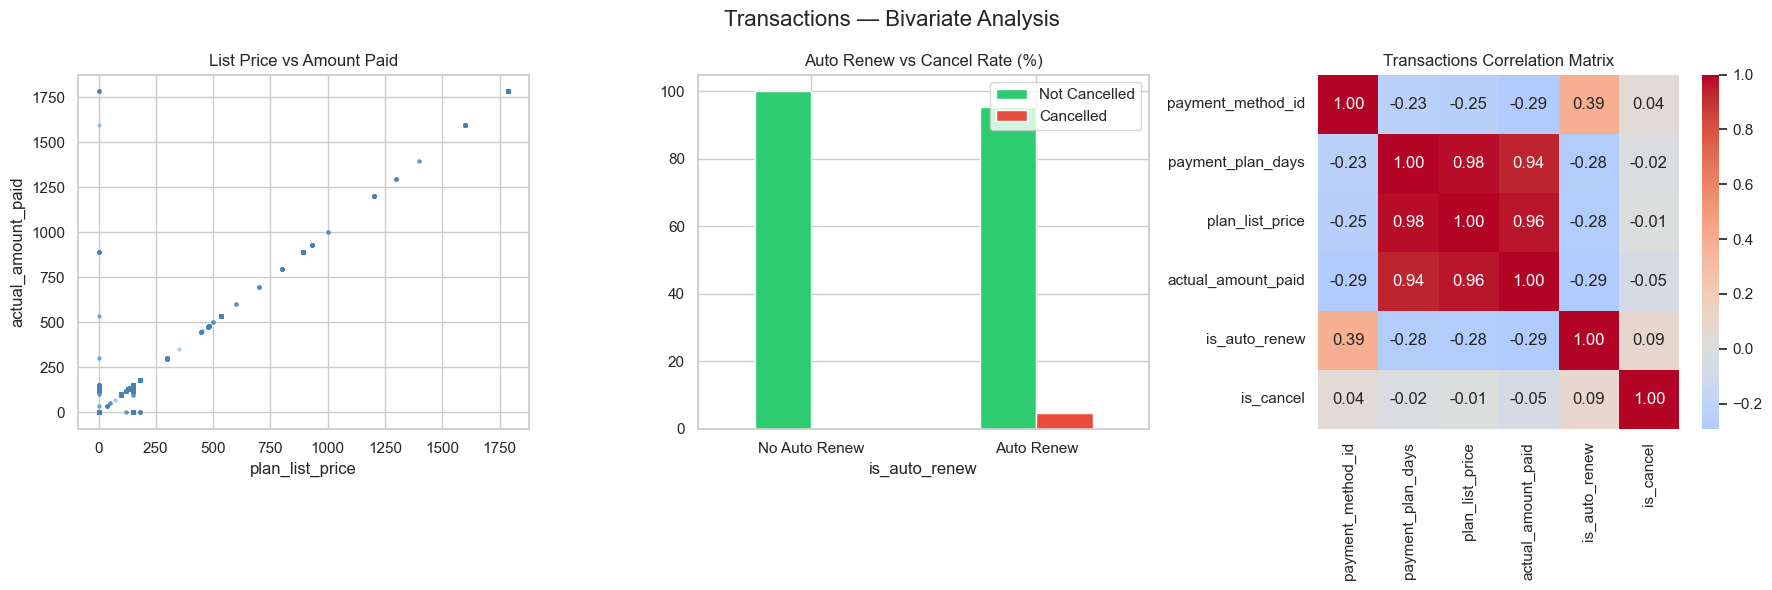

In [31]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Transactions — Bivariate Analysis', fontsize=16)

# list price vs amount paid
sample_trans = trans.sample(50_000, random_state=42)
axes[0].scatter(sample_trans['plan_list_price'],
                sample_trans['actual_amount_paid'],
                alpha=0.3, s=5, color='steelblue')
axes[0].set_title('List Price vs Amount Paid')
axes[0].set_xlabel('plan_list_price')
axes[0].set_ylabel('actual_amount_paid')

# auto renew vs cancel rate
ct = pd.crosstab(trans['is_auto_renew'], trans['is_cancel'],
                 normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Auto Renew vs Cancel Rate (%)')
axes[1].set_xticklabels(['No Auto Renew','Auto Renew'], rotation=0)
axes[1].legend(['Not Cancelled','Cancelled'])

# correlation heatmap
corr = trans.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', ax=axes[2])
axes[2].set_title('Transactions Correlation Matrix')

plt.tight_layout()
plt.show()

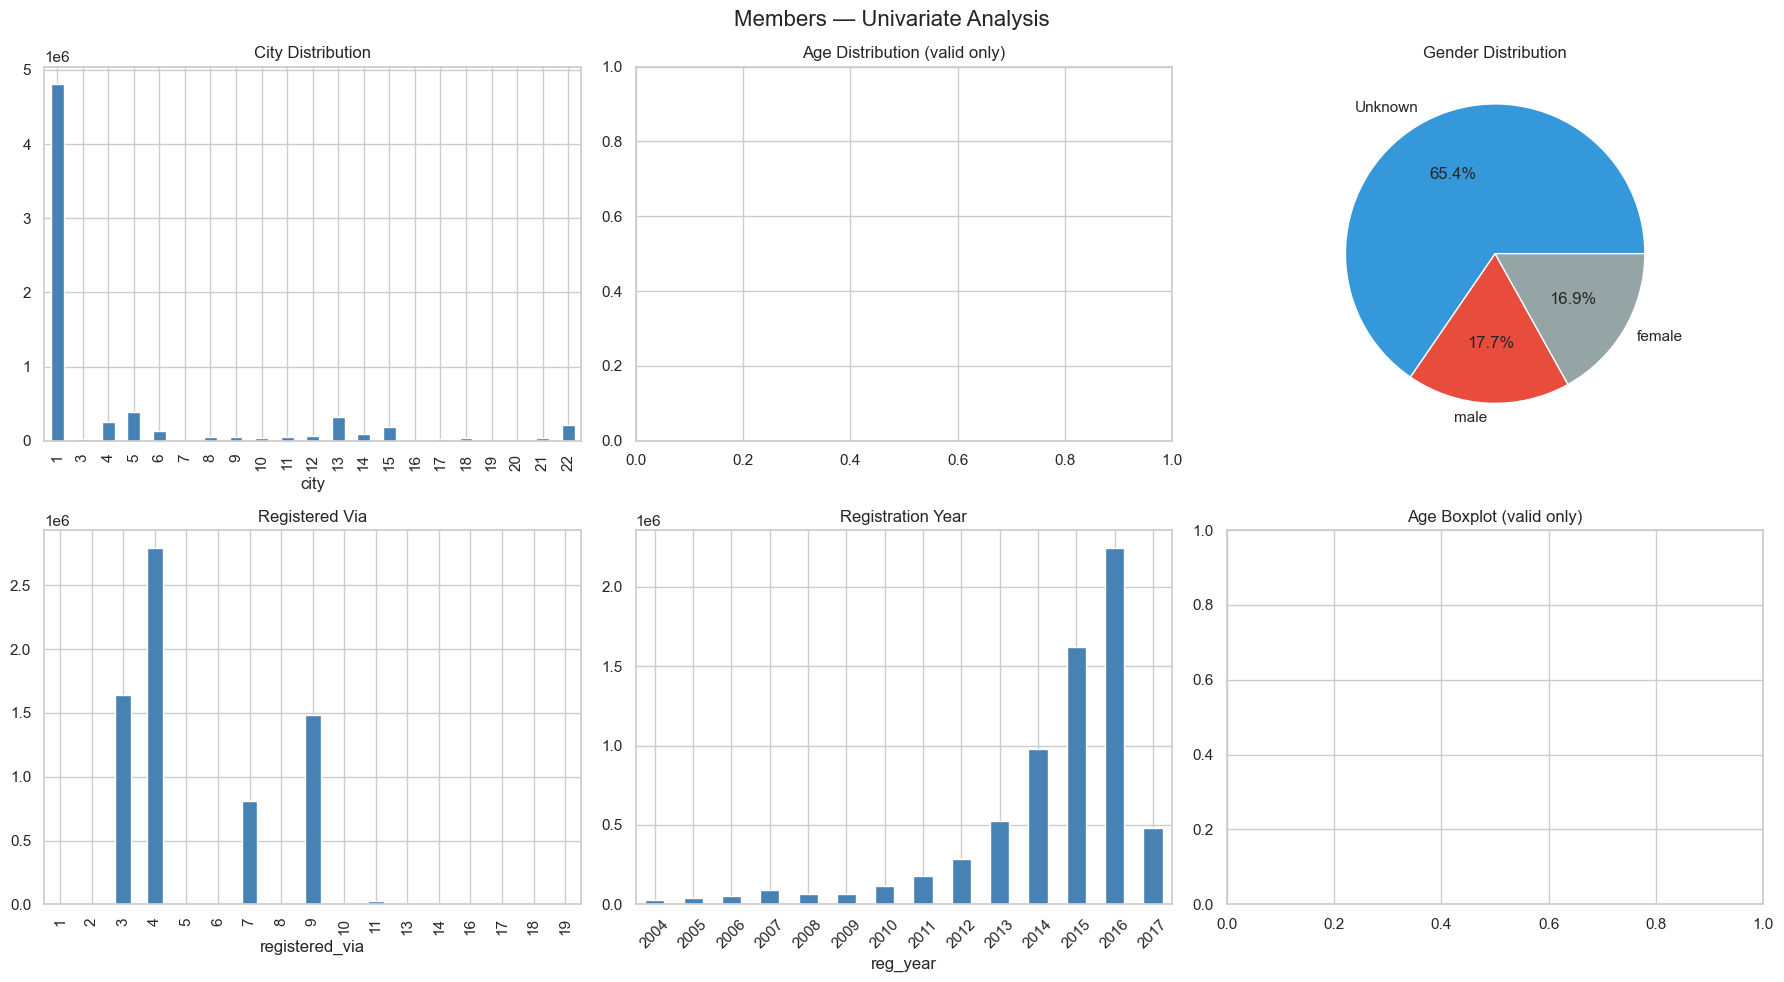

In [32]:
# 3- MEMBERS 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Members — Univariate Analysis', fontsize=16)

# city
members['city'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('City Distribution')

# age valid only
valid_age = members[(members['bd'] > 0) & (members['bd'] < 100)]
sns.histplot(valid_age['bd'], bins=30, ax=axes[0,1],
             color='steelblue', kde=True)
axes[0,1].set_title('Age Distribution (valid only)')

# gender pie
gender_counts = members['gender'].value_counts(dropna=False)
gender_counts.index = gender_counts.index.fillna('Unknown')
axes[0,2].pie(gender_counts, labels=gender_counts.index,
              autopct='%1.1f%%',
              colors=['#3498db','#e74c3c','#95a5a6'])
axes[0,2].set_title('Gender Distribution')

# registered_via
members[members['registered_via'] >= 0]['registered_via']\
    .value_counts().sort_index()\
    .plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Registered Via')

# registration year
members['reg_year'] = pd.to_datetime(
    members['registration_init_time'],
    format='%Y%m%d', errors='coerce').dt.year
members['reg_year'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Registration Year')
axes[1,1].tick_params(axis='x', rotation=45)

# age boxplot
sns.boxplot(y=valid_age['bd'], ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Age Boxplot (valid only)')

plt.tight_layout()
plt.show()


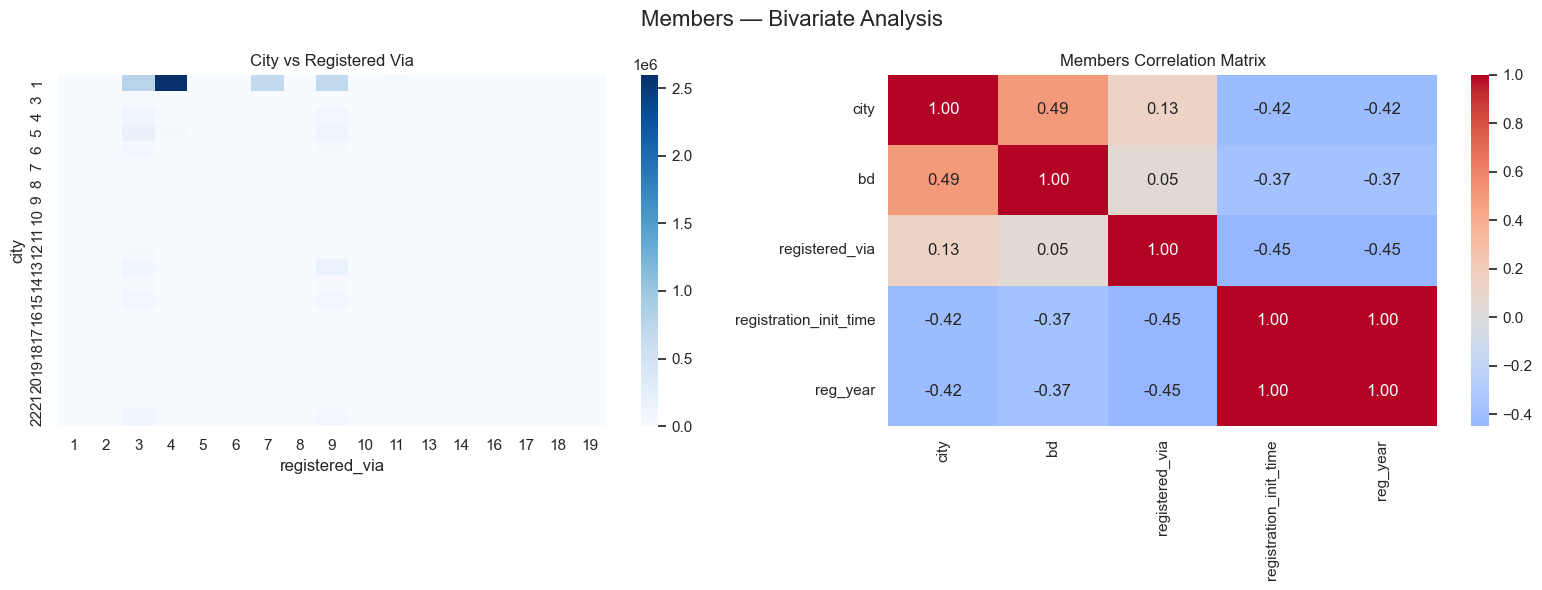

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Members — Bivariate Analysis', fontsize=16)

# city vs registered_via
ct_members = pd.crosstab(
    members['city'],
    members[members['registered_via'] >= 0]['registered_via'])
sns.heatmap(ct_members, cmap='Blues', ax=axes[0])
axes[0].set_title('City vs Registered Via')

# correlation heatmap
corr_members = members.select_dtypes(include='number').corr()
sns.heatmap(corr_members, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Members Correlation Matrix')

plt.tight_layout()
plt.show()


helper funs

In [37]:
from scipy import stats
def check_missing(df, name):
    print(f"\n{'='*60}")
    print(f"{name} — MISSING VALUES")
    print(f"{'='*60}")
    missing = df.isnull().sum()
    pct     = (missing / len(df)) * 100
    result  = pd.DataFrame({'missing': missing, 'pct': pct})
    result  = result[result['missing'] > 0].sort_values('pct', ascending=False)
    if result.empty:
        print("No missing values found")
    else:
        print(result)

In [38]:
def check_duplicates(df, name, subset=None):
    print(f"\n{'='*60}")
    print(f"{name} — DUPLICATES")
    print(f"{'='*60}")
    dups = df.duplicated(subset=subset).sum()
    print(f"Total duplicate rows : {dups:,}")
    print(f"Percentage           : {dups/len(df)*100:.2f}%")

In [43]:

def check_outliers_zscore(df, name, cols):
    print(f"\n{'='*60}")
    print(f"{name} — OUTLIERS (Z-Score > 3)")
    print(f"{'='*60}")
    for col in cols:
        clean = df[col].dropna()
        z     = np.abs(stats.zscore(clean))
        out   = (z > 3).sum()
        print(f"{col:30} : {out:>10,} outliers ({out/len(clean)*100:.2f}%)")

In [ ]:
def check_inconsistencies(df, name, checks):
    print(f"\n{'='*60}")
    print(f"{name} — INCONSISTENCIES")
    print(f"{'='*60}")
    for label, mask in checks.items():
        count = mask.sum()
        print(f"{label:40} : {count:>10,} rows ({count/len(df)*100:.2f}%)")

**data quality**

In [59]:
#user_logs
check_missing(logs, 'USER LOGS')



USER LOGS — MISSING VALUES
No missing values found


In [60]:
check_duplicates(logs, 'USER LOGS', subset=['msno', 'date'])


USER LOGS — DUPLICATES
Total duplicate rows : 0
Percentage           : 0.00%


In [68]:
print("\n— OUTLIERS (based on 1M sample — below 1st or above 99th pct) —")

sample = logs.sample(1_000_000, random_state=42)

num_cols = ['num_25','num_50','num_75','num_985','num_100','num_unq','total_secs']

for col in num_cols:
    q01 = sample[col].quantile(0.01)
    q99 = sample[col].quantile(0.99)
    out = ((sample[col] < q01) | (sample[col] > q99)).sum()
    print(f"  {col:15} : {out:>10,} ({out/len(sample)*100:.2f}%) | range: [{q01:.1f} — {q99:.1f}]")

del sample


— OUTLIERS (based on 1M sample — below 1st or above 99th pct) —
  num_25          :      9,674 (0.97%) | range: [0.0 — 61.0]
  num_50          :      9,306 (0.93%) | range: [0.0 — 16.0]
  num_75          :      9,332 (0.93%) | range: [0.0 — 8.0]
  num_985         :      9,478 (0.95%) | range: [0.0 — 9.0]
  num_100         :      9,985 (1.00%) | range: [0.0 — 182.0]
  num_unq         :      9,874 (0.99%) | range: [1.0 — 156.0]
  total_secs      :     20,000 (2.00%) | range: [77.9 — 44683.2]


In [62]:
print(f"\n{'='*60}")
print("USER LOGS — INCONSISTENCIES")
print(f"{'='*60}")

total = len(logs)

c1 = (logs['total_secs'] <= 0).sum()
print(f"  {'total_secs <= 0 (invalid)':40} : {c1:>10,} ({c1/total*100:.2f}%)")
del c1

c2 = (logs['total_secs'] > 86400).sum()
print(f"  {'total_secs > 86400 (more than 1 day)':40} : {c2:>10,} ({c2/total*100:.2f}%)")
del c2

ghost = (logs['num_25']  == 0) & \
        (logs['num_50']  == 0) & \
        (logs['num_75']  == 0) & \
        (logs['num_985'] == 0) & \
        (logs['num_100'] == 0)
c3 = ghost.sum()
print(f"  {'ghost session (all play counts = 0)':40} : {c3:>10,} ({c3/total*100:.2f}%)")
del ghost, c3

c4 = (logs['num_unq'] == 0).sum()
print(f"  {'num_unq = 0 (no songs played)':40} : {c4:>10,} ({c4/total*100:.2f}%)")
del c4

c5 = (logs['num_100'] > logs['num_unq']).sum()
print(f"  {'num_100 > num_unq (impossible)':40} : {c5:>10,} ({c5/total*100:.2f}%)")
del c5



USER LOGS — INCONSISTENCIES
  total_secs <= 0 (invalid)                :     61,493 (0.01%)
  total_secs > 86400 (more than 1 day)     :    147,193 (0.04%)
  ghost session (all play counts = 0)      :          0 (0.00%)
  num_unq = 0 (no songs played)            :          0 (0.00%)
  num_100 > num_unq (impossible)           : 118,520,340 (28.87%)


In [39]:
#TRANSACTIONS
check_missing(trans, 'TRANSACTIONS')


TRANSACTIONS — MISSING VALUES
No missing values found


In [40]:
check_duplicates(trans, 'TRANSACTIONS')


TRANSACTIONS — DUPLICATES
Total duplicate rows : 3,339
Percentage           : 0.01%


In [45]:
check_outliers_zscore(trans, 'TRANSACTIONS', [
    'payment_plan_days',
    'plan_list_price',
    'actual_amount_paid'
])


TRANSACTIONS — OUTLIERS (Z-Score > 3)
payment_plan_days              :    436,852 outliers (1.90%)
plan_list_price                :    366,169 outliers (1.59%)
actual_amount_paid             :    374,629 outliers (1.63%)


In [46]:

trans['transaction_date']       = pd.to_datetime(trans['transaction_date'],       format='%Y%m%d', errors='coerce')
trans['membership_expire_date'] = pd.to_datetime(trans['membership_expire_date'], format='%Y%m%d', errors='coerce')

In [47]:
check_inconsistencies(trans, 'TRANSACTIONS', {
    'payment_plan_days = 0 (invalid)'          : trans['payment_plan_days'] == 0,
    'plan_list_price = 0 (free/error)'         : trans['plan_list_price'] == 0,
    'actual_amount_paid = 0 (free/error)'      : trans['actual_amount_paid'] == 0,
    'expire date before 2015 (invalid)'        : trans['membership_expire_date'].dt.year < 2015,
    'expire date after 2020 (suspicious)'      : trans['membership_expire_date'].dt.year > 2020,
    'amount paid > list price (overpaid)'      : trans['actual_amount_paid'] > trans['plan_list_price'],
    'is_auto_renew not binary'                 : ~trans['is_auto_renew'].isin([0, 1]),
    'is_cancel not binary'                     : ~trans['is_cancel'].isin([0, 1]),
})



TRANSACTIONS — INCONSISTENCIES
payment_plan_days = 0 (invalid)          :    872,342 rows (3.80%)
plan_list_price = 0 (free/error)         :  1,516,957 rows (6.60%)
actual_amount_paid = 0 (free/error)      :  1,218,324 rows (5.30%)
expire date before 2015 (invalid)        :      9,840 rows (0.04%)
expire date after 2020 (suspicious)      :        909 rows (0.00%)
amount paid > list price (overpaid)      :    859,686 rows (3.74%)
is_auto_renew not binary                 :          0 rows (0.00%)
is_cancel not binary                     :          0 rows (0.00%)


In [48]:
#MEMBERS
check_missing(members, 'MEMBERS')



MEMBERS — MISSING VALUES
        missing        pct
gender  4429505  65.433528


In [58]:
check_duplicates(members.reset_index(), 'MEMBERS', subset=['msno'])


MEMBERS — DUPLICATES
Total duplicate rows : 0
Percentage           : 0.00%


In [50]:
check_outliers_zscore(members, 'MEMBERS', ['bd', 'city', 'registered_via'])


MEMBERS — OUTLIERS (Z-Score > 3)
bd                             :     22,350 outliers (0.33%)
city                           :    241,244 outliers (3.56%)
registered_via                 :      9,431 outliers (0.14%)


In [ ]:
members['registration_init_time'] = pd.to_datetime( members['registration_init_time'], format='%Y%m%d', errors='coerce')


In [52]:

check_inconsistencies(members, 'MEMBERS', {
    'bd = 0 (missing age)'                     : members['bd'] == 0,
    'bd < 0 (impossible age)'                  : members['bd'] < 0,
    'bd > 100 (impossible age)'                : members['bd'] > 100,
    'registered_via = -1 (invalid)'            : members['registered_via'] == -1,
    'registration before 2004 (suspicious)'    : members['registration_init_time'].dt.year < 2004,
    'gender missing'                           : members['gender'].isnull(),
})



MEMBERS — INCONSISTENCIES
bd = 0 (missing age)                     :  4,540,215 rows (67.07%)
bd < 0 (impossible age)                  :        274 rows (0.00%)
bd > 100 (impossible age)                :      5,377 rows (0.08%)
registered_via = -1 (invalid)            :          0 rows (0.00%)
registration before 2004 (suspicious)    :          0 rows (0.00%)
gender missing                           :  4,429,505 rows (65.43%)


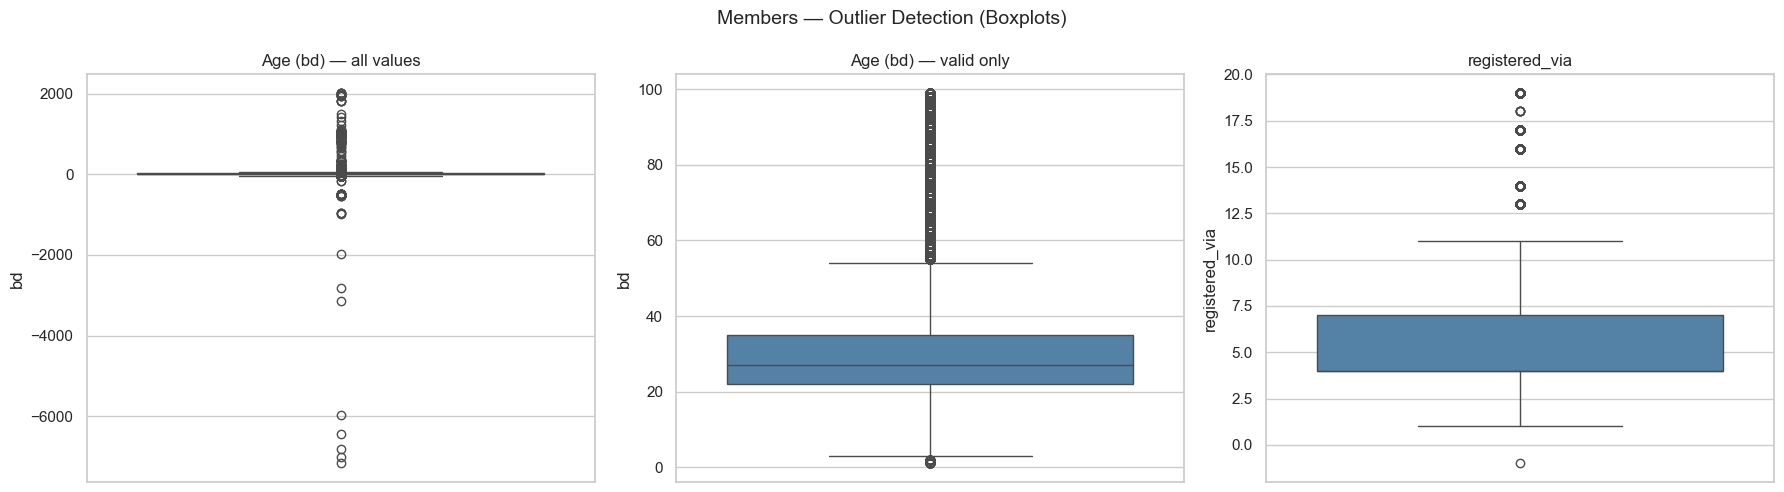

In [53]:
# — Boxplot for age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Members — Outlier Detection (Boxplots)', fontsize=14)

sns.boxplot(y=members['bd'], ax=axes[0], color='steelblue')
axes[0].set_title('Age (bd) — all values')

valid_age = members[(members['bd'] > 0) & (members['bd'] < 100)]
sns.boxplot(y=valid_age['bd'], ax=axes[1], color='steelblue')
axes[1].set_title('Age (bd) — valid only')

sns.boxplot(y=members['registered_via'], ax=axes[2], color='steelblue')
axes[2].set_title('registered_via')

plt.tight_layout()
plt.show()


In [54]:
#train
check_missing(train, 'TRAIN')


TRAIN — MISSING VALUES
No missing values found


In [55]:
check_duplicates(train, 'TRAIN', subset=['msno'])


TRAIN — DUPLICATES
Total duplicate rows : 881,701
Percentage           : 44.90%


In [56]:

check_inconsistencies(train, 'TRAIN', {
    'is_churn not binary'  : ~train['is_churn'].isin([0, 1]),
})


TRAIN — INCONSISTENCIES
is_churn not binary                      :          0 rows (0.00%)


C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\2481380063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=train,
C:\Users\workstation\AppData\Local\Temp\ipykernel_18132\2481380063.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Churned','Churned'])


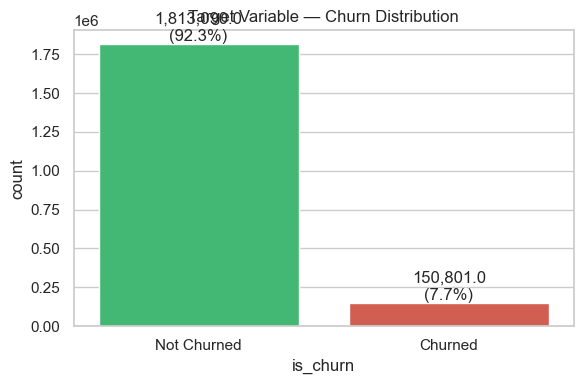

In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='is_churn', data=train,
              palette=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('Target Variable — Churn Distribution')
ax.set_xticklabels(['Not Churned','Churned'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(train)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()